# Kapitola 1: Náhodné jevy a jejich pravděpodobnost

## 1.1 Náhodné jevy

**Definice 1.1**  
Náhodný pokus je libovolný proces, jehož výsledek není jednoznačně určen podmínkami, za nichž je prováděn. Lze pouze popsat množinu možných výsledků pokusu $\Omega$.

**Definice 1.2**  
Náhodný jev je jakékoli ověřitelné tvrzení o výsledku náhodného pokusu. Jev A je podmnožinou množiny možných výsledků Ω.

**Definice 1.3 (Operace s jevy)**  
- Ω: jev jistý  
- ∅: jev nemožný  
- $ \overline{A} $: doplněk jevu A  
- $ A \cap B $: průnik jevů A a B  
- $ A \cup B $: sjednocení jevů A a B  
- $ A \subseteq B $: A je podjevem B  
- $ A \cap B = \emptyset $: neslučitelné (disjunktní) jevy  
- $ A_1 \cup A_2 \cup \dots \cup A_n = \Omega $: úplný systém jevů
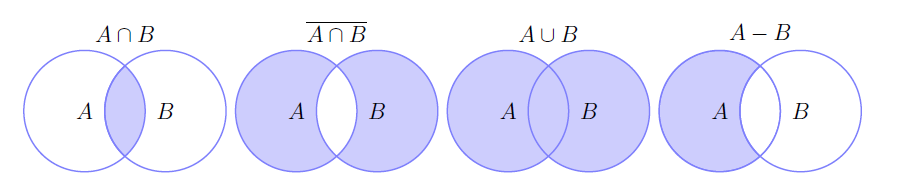

**Věta 1.4 (Vlastnosti náhodných jevů)**  
- Komutativita: $ A \cup B \equiv B \cup A $, $ A \cap B \equiv B \cap A $  
- Asociativita: $ (A \cup B) \cup C \equiv A \cup (B \cup C) $, $ (A \cap B) \cap C \equiv A \cap (B \cap C) $  
- Distributivita: $ (A \cap B) \cup C = (A \cup C) \cap (B \cup C) $, $ (A \cup B) \cap C = (A \cap C) \cup (B \cap C) $  
- Komplement: $ A \cap \overline{A} = \emptyset $, $ A \cup \overline{A} = \Omega $  
- De Morganova pravidla: $ \overline{A \cup B} = \overline{A} \cap \overline{B} $, $ \overline{A \cap B} = \overline{A} \cup \overline{B} $


In [4]:
import random

# Množina možných výsledků náhodného pokusu (např. hod kostkou)
omega = [1, 2, 3, 4, 5, 6]

# Definujeme jev A: padne sudé číslo
jev_A = {2, 4, 6}

# Provedeme simulaci 10 000 pokusů
n = 10000
vysledky = [random.choice(omega) for _ in range(n)]

# Vyhodnotíme, kolikrát nastal jev A
pocet_A = sum(1 for v in vysledky if v in jev_A)

# Odhad pravděpodobnosti jevu A
P_A = pocet_A / n
print(f'Odhad pravděpodobnosti jevu A (sudé číslo): {P_A:.4f}')

Odhad pravděpodobnosti jevu A (sudé číslo): 0.4912


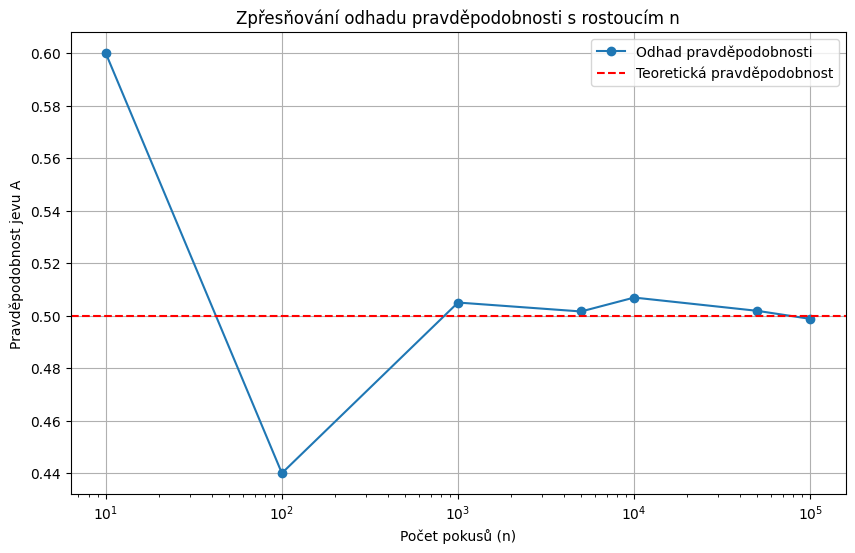

In [5]:
import random
import matplotlib.pyplot as plt

# Množina možných výsledků
omega = [1, 2, 3, 4, 5, 6]
jev_A = {2, 4, 6}  # sudá čísla

# Různé počty pokusů
n_values = [10, 100, 1000, 5000, 10000, 50000, 100000]
odhad_pravdepodobnosti = []

for n in n_values:
    vysledky = [random.choice(omega) for _ in range(n)]
    pocet_A = sum(1 for v in vysledky if v in jev_A)
    P_A = pocet_A / n
    odhad_pravdepodobnosti.append(P_A)

# Teoretická pravděpodobnost
teoreticka = len(jev_A) / len(omega)

# Vykreslení grafu
plt.figure(figsize=(10, 6))
plt.plot(n_values, odhad_pravdepodobnosti, marker='o', label='Odhad pravděpodobnosti')
plt.axhline(teoreticka, color='red', linestyle='--', label='Teoretická pravděpodobnost')
plt.xscale('log')
plt.xlabel('Počet pokusů (n)')
plt.ylabel('Pravděpodobnost jevu A')
plt.title('Zpřesňování odhadu pravděpodobnosti s rostoucím n')
plt.legend()
plt.grid(True)
plt.show()


## 1.2 Definice pravděpodobnosti

Pravděpodobnost jevu 
 každému jevu $A$ přiřazuje reálné číslo $P(A)$,

 lze ji chápat jako předpověď poměrných četností výsledků  při mnohonásobném opakování daného pokusu,

 lze ji interpretovat jako kvantitativní ohodnocení stupně jistoty.


**Definice 1.5 (Klasická definice)**  
Je-li množina Ω konečná a všechny elementární jevy jsou stejně pravděpodobné, pak pravděpodobnost jevu A je:  
$$ P(A) = \frac{\text{počet příznivých výsledků}}{\text{počet všech možných výsledků}} $$

**Definice 1.6 (Relativní četnost)**  
$$ P(A) \approx \frac{\text{počet výskytů jevu A}}{\text{počet pokusů}} $$

**Definice 1.7 (Geometrická definice)**  
$$ P(A) = \frac{\text{obsah oblasti A}}{\text{obsah celého prostoru Ω}} $$

**Definice 1.8 (Axiomatická definice - Kolmogorov)**  
https://cs.wikipedia.org/wiki/Andrej_Nikolajevi%C4%8D_Kolmogorov

Pravděpodobnostní prostor je trojice $ (\Omega, \mathcal{A}, P) $, kde:
- $ \mathcal{A} $ je σ-algebra podmnožin Ω
- $ P $ je pravděpodobnostní míra, která splňuje:
  - $ P(\Omega) = 1 $
  - $ P(A) \geq 0 $
  - Pro disjunktní jevy $ A_i $: $ P(\bigcup_i A_i) = \sum_i P(A_i) $

https://cs.wikipedia.org/wiki/Kolmogorovovy_axiomy_pravd%C4%9Bpodobnosti


Metodou založenou na opakovaném náhodném pokusu, která vede k určitému výsledku, je metoda Monte Carlo. Tato metoda se často využívá při řešení problémů, které jsou složité na analýzu nebo kdy je potřeba zohlednit náhodnost a nejistotu. 
https://cs.wikipedia.org/wiki/Metoda_Monte_Carlo 

Odhad geometrické pravděpodobnosti (bod v kruhu): 0.7858
Odhad čísla π: 3.1431


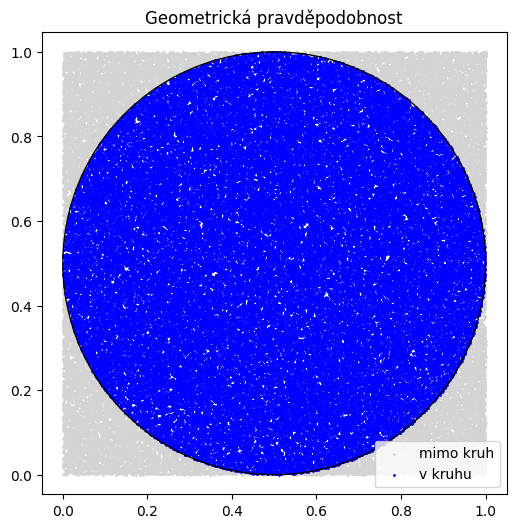

In [1]:
# Geometrická pravděpodobnost: náhodný bod v čtverci, jev A = bod v kruhu se středem (0.5, 0.5) a poloměrem 0.5
# Ukázka odhadu čísla π pomocí geometrické definice pravděpodobnosti
# Vycházíme z předpokladu, že poměr obsahu kruhu k obsahu čtverce se rovná pravděpodobnosti, že náhodný bod leží v kruhu
# Vzorec pro obsah kruhu: S_kruh = π * r^2
# Vzorec pro obsah čtverce: S_ctverec = (2r)^2 = 4 * r^2
# Poměr: P_A = S_kruh / S_ctverec = (π * r^2) / (4 * r^2) = π / 4
import numpy as np
import matplotlib.pyplot as plt
n = 100000
x = np.random.rand(n)
y = np.random.rand(n)

# Jev A: bod leží v kruhu
jev_A = (x - 0.5)**2 + (y - 0.5)**2 <= 0.25

# Odhad pravděpodobnosti
P_A = np.sum(jev_A) / n
print(f'Odhad geometrické pravděpodobnosti (bod v kruhu): {P_A:.4f}')
print(f'Odhad čísla π: {P_A * 4:.4f}')

# Vizualizace
plt.figure(figsize=(6,6))
plt.scatter(x[~jev_A], y[~jev_A], color='lightgray', s=1, label='mimo kruh')
plt.scatter(x[jev_A], y[jev_A], color='blue', s=1, label='v kruhu')
circle = plt.Circle((0.5, 0.5), 0.5, color='black', fill=False)
plt.gca().add_artist(circle)
plt.title('Geometrická pravděpodobnost')
plt.legend()
plt.axis('equal')
plt.show()

Další slavným příkladem využití geometrické pravděpodobnosti pro odhad čísla $\pi$ je Buffonova jehla https://cs.wikipedia.org/wiki/Buffonova_jehla

In [5]:
import random
import math

# Parametry Buffonova experimentu
l = 1.0  # délka jehly
d = 2.0  # vzdálenost mezi čarami (d > l)
n = 1000  # počet pokusů
k = 0  # počet zásahů čáry

# Simulace hodů jehlou
for _ in range(n):
    # Náhodná vzdálenost středu jehly od nejbližší čáry (0 až d/2)
    y = random.uniform(0, d / 2)
    # Náhodný úhel mezi jehlou a čarami (0 až pi/2)
    theta = random.uniform(0, math.pi / 2)
    
    # Podmínka zásahu: jehla protne čáru
    if y <= (l / 2) * math.sin(theta):
        k += 1

# Výpočet odhadu π
if k > 0:
    pi_estimate = (2 * l * n) / (d * k)
    print(f"Odhad hodnoty π pomocí Buffonovy jehly: {pi_estimate:.6f}")
else:
    print("Žádný zásah čáry nenastal, nelze odhadnout π.")



Odhad hodnoty π pomocí Buffonovy jehly: 3.215434


## 1.3 Vlastnosti pravděpodobnosti

**Věta 1.9**  
Pro jevy A, B platí:
- $ 0 \leq P(A) \leq 1 $, $ P(\emptyset) = 0 $
- $ P(\overline{A}) = 1 - P(A) $
- $ P(A \cup B) = P(A) + P(B) - P(A \cap B) $
- Je-li $ A \subseteq B $, pak $ P(A) \leq P(B) $

**Věta 1.10 (Limitní vlastnosti)**  
- Jsou-li $ A_1 \subseteq A_2 \subseteq \dots $, pak $ P(\bigcup_n A_n) = \lim_{n \to \infty} P(A_n) $  
- Jsou-li $ A_1 \supseteq A_2 \supseteq \dots $, pak $ P(\bigcap_n A_n) = \lim_{n \to \infty} P(A_n) $
